Membaca dan menyaring data CSV...
Menjalankan optimasi NNLS dengan Regularisasi Tikhonov...

 HASIL BOBOT PARTIKEL FINAL (Masukkan ke PRISTINE.txt)
Layer Energi ke- 1 (PBP_160_5.csv) :       0 partikel
Layer Energi ke- 2 (  PBP_159.csv) :  368457 partikel
Layer Energi ke- 3 (PBP_157_5.csv) : 1000000 partikel
Layer Energi ke- 4 (  PBP_156.csv) :       0 partikel
Layer Energi ke- 5 (PBP_154_5.csv) :       0 partikel
Layer Energi ke- 6 (  PBP_153.csv) :   94675 partikel
Layer Energi ke- 7 (PBP_151_5.csv) :  267984 partikel
Layer Energi ke- 8 (  PBP_150.csv) :       0 partikel
Layer Energi ke- 9 (PBP_148_5.csv) :       0 partikel
Layer Energi ke-10 (  PBP_148.csv) :  223571 partikel



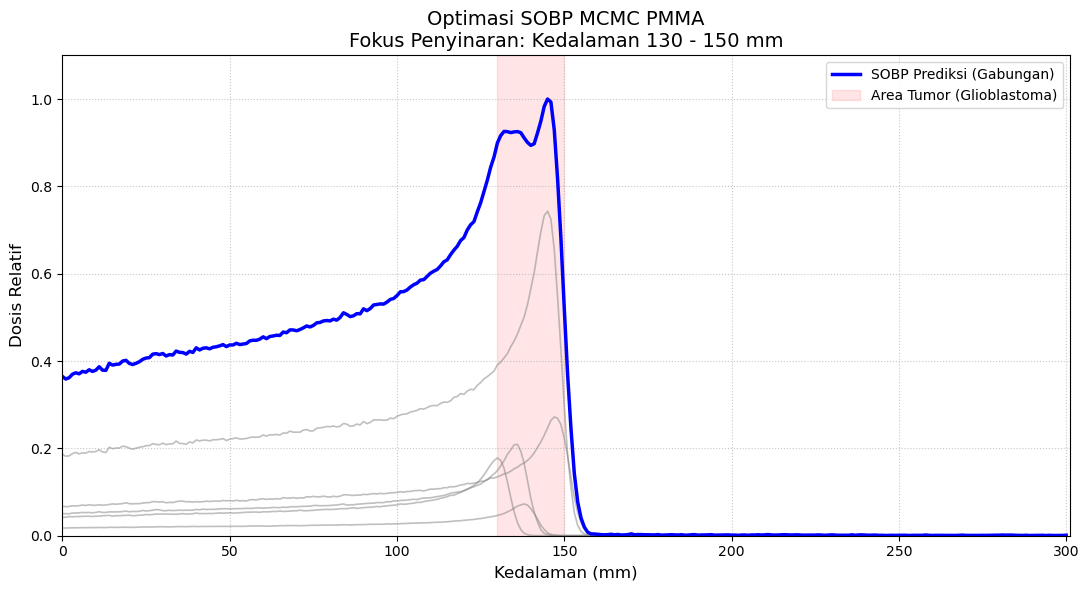

In [56]:
import pandas as pd
import numpy as np
from scipy.optimize import nnls
import matplotlib.pyplot as plt

# ==========================================
# 1. PENGATURAN DATA & TARGET
# ==========================================
# Tuliskan nama ke-10 file CSV Anda di list ini. 
# WAJIB berurutan dari energi TERTINGGI (paling dalam) ke TERENDAH.
file_list = [
    "PBP_160_5.csv", "PBP_159.csv", "PBP_157_5.csv", 
    "PBP_156.csv", "PBP_154_5.csv", "PBP_153.csv", 
    "PBP_151_5.csv", "PBP_150.csv", "PBP_148_5.csv", "PBP_148.csv"
] # <-- Sesuaikan nama-nama string ini dengan file asli di laptop Anda

# Target Kedalaman dalam satuan bin (Asumsi 1 bin = 1 mm)
target_start = 130  
target_end = 150    
dosis_ideal = 100.0 # Patokan dosis seragam di area tumor

# ==========================================
# 2. EKSTRAKSI DATA PRISTINE PEAK (TOPAS)
# ==========================================
dose_matrix = []

print("Membaca dan menyaring data CSV...")
for file in file_list:
    try:
        # Membaca CSV, mengabaikan header TOPAS '#', tanpa nama kolom
        df = pd.read_csv(file, comment='#', header=None)
        
        # iloc[:, -1] memastikan Python HANYA mengambil kolom paling kanan (Dosis)
        dose_array = df.iloc[:, -1].values
        dose_matrix.append(dose_array)
    except FileNotFoundError:
        print(f"Peringatan: File '{file}' tidak ditemukan di direktori.")

# Menyeragamkan ukuran baris untuk mencegah error dimensi Numpy
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]

# Membentuk Matriks D (Dimensi: ZBins x Jumlah Energi)
D = np.column_stack(dose_matrix_cropped)

# ==========================================
# 3. ALGORITMA OPTIMASI (DENGAN PENALTI TIKHONOV)
# ==========================================
target_start = 130
target_end = 150

# Potong matriks hanya untuk fokus di area tumor dan belakangnya
D_opt = D[target_start:, :]
t_opt = np.zeros(min_len - target_start)
t_opt[0:(target_end - target_start + 1)] = 1.0  # Target dosis flat

# NORMALISASI MATRIKS (Sangat penting agar penalti bekerja adil)
max_d = np.max(D_opt)
D_opt_norm = D_opt / max_d

# MENAMBAHKAN REGULARISASI TIKHONOV (Mencegah beam bernilai 0)
alpha = 0.003 # Semakin besar nilai ini, bobot semakin dipaksa merata ke semua energi. 
             # Jika dirasa kurang rata, naikkan ke 1.0 atau 2.0.

# Menyuntikkan matriks identitas sebagai "hukuman" matematis
D_reg = np.vstack([D_opt_norm, alpha * np.eye(D_opt_norm.shape[1])])
t_reg = np.concatenate([t_opt, np.zeros(D_opt_norm.shape[1])])

print("Menjalankan optimasi NNLS dengan Regularisasi Tikhonov...")
w_norm, residual = nnls(D_reg, t_reg)

# Mengembalikan skala bobot ke aslinya
w = w_norm / max_d

# ==========================================
# 4. HASIL BOBOT (SKALA 100.000 PARTIKEL)
# ==========================================
max_w = np.max(w)

if max_w > 0:
    bobot_partikel = np.round((w / max_w) * 1000000).astype(int)
else:
    bobot_partikel = np.zeros(len(w), dtype=int)

print(f"\n{'='*55}")
print(" HASIL BOBOT PARTIKEL FINAL (Masukkan ke PRISTINE.txt)")
print(f"{'='*55}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer Energi ke-{i+1:2d} ({file_list[i]:>13}) : {bobot:7d} partikel")
print(f"{'='*55}\n")

# ==========================================
# 5. VISUALISASI SOBP GABUNGAN
# ==========================================
# Prediksi seluruh phantom menggunakan bobot asli hasil NNLS
SOBP_prediksi = D.dot(w)

# Skala visualisasi agar puncak tertingginya menyentuh angka 1.0 (Relatif)
max_dose = np.max(SOBP_prediksi)
SOBP_prediksi_norm = SOBP_prediksi / max_dose
D_norm = D / max_dose 

kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(11, 6))

# Plot masing-masing Pristine Beam
for i in range(len(w)):
    if w[i] > 0:
        plt.plot(kedalaman_mm, D_norm[:, i] * w[i], color='gray', alpha=0.5, linewidth=1.2)

# Plot hasil SOBP
plt.plot(kedalaman_mm, SOBP_prediksi_norm, 'b-', linewidth=2.5, label='SOBP Prediksi (Gabungan)')

# Area Arsir Tumor
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Tumor (Glioblastoma)')

plt.title(f'Optimasi SOBP MCMC PMMA\nFokus Penyinaran: Kedalaman {target_start} - {target_end} mm', fontsize=14)
plt.xlabel('Kedalaman (mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Membaca dan menyaring data CSV...
Menjalankan optimasi L-BFGS-B (Normalized)...

 HASIL BOBOT PARTIKEL L-BFGS-B (Masukkan ke PRISTINE.txt)
Layer Energi ke- 1 (PBP_160_5.csv) :   50576 partikel
Layer Energi ke- 2 (  PBP_159.csv) :    1034 partikel
Layer Energi ke- 3 (PBP_157_5.csv) :   57449 partikel
Layer Energi ke- 4 (  PBP_156.csv) :   83659 partikel
Layer Energi ke- 5 (PBP_154_5.csv) :   49060 partikel
Layer Energi ke- 6 (  PBP_153.csv) :   41249 partikel
Layer Energi ke- 7 (PBP_151_5.csv) :   70642 partikel
Layer Energi ke- 8 (  PBP_150.csv) :    2407 partikel
Layer Energi ke- 9 (PBP_148_5.csv) :       0 partikel
Layer Energi ke-10 (  PBP_148.csv) :  100000 partikel



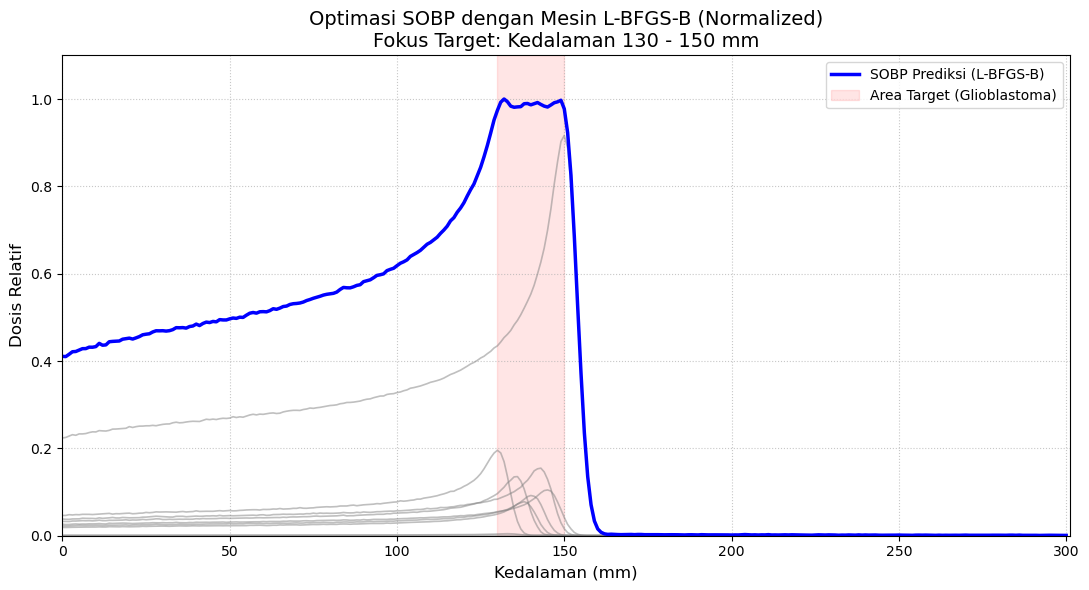

In [69]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# 1. PENGATURAN DATA & TARGET
# ==========================================
file_list = [
    "PBP_160_5.csv", "PBP_159.csv", "PBP_157_5.csv", 
    "PBP_156.csv", "PBP_154_5.csv", "PBP_153.csv", 
    "PBP_151_5.csv", "PBP_150.csv", "PBP_148_5.csv", "PBP_148.csv"
]

target_start = 130
target_end = 150

# ==========================================
# 2. EKSTRAKSI DATA PRISTINE PEAK
# ==========================================
dose_matrix = []
print("Membaca dan menyaring data CSV...")
for file in file_list:
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# ==========================================
# 3. KUNCI PERBAIKAN: NORMALISASI MATRIKS 
# ==========================================
# Mengubah skala matriks yang sangat kecil menjadi skala 0.0 - 1.0
D_max = np.max(D)
D_norm = D / D_max

# Target dosis SOBP diubah menjadi 1.0 mengikuti normalisasi
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 4. FUNGSI LOSS KUSTOM (L-BFGS-B)
# ==========================================
def loss_function(w, D_mat, target):
    prediksi = D_mat.dot(w)
    
    # Menghitung MSE HANYA di rentang 130 - 150 mm
    error_tumor = np.mean((prediksi[target_start:target_end+1] - target[target_start:target_end+1])**2)
    
    # Penalti penghalus mikroskopis (mencegah beam dimatikan tapi tidak merusak puncak)
    smoothness_penalty = 0.000000005 * np.sum(w**2)
    
    return error_tumor + smoothness_penalty

# ==========================================
# 5. EKSEKUSI OPTIMASI L-BFGS-B
# ==========================================
print("Menjalankan optimasi L-BFGS-B (Normalized)...")

# Tebakan awal diubah menjadi 0.5 karena skala maksimal D_norm adalah 1.0
w0 = np.ones(D_norm.shape[1]) * 0.2 

batas = [(0, None) for _ in range(D_norm.shape[1])]
hasil = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=batas)

w_terbaik = hasil.x

# ==========================================
# 6. KONVERSI KE JUMLAH PARTIKEL (SKALA 100k)
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * 100000).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

print(f"\n{'='*55}")
print(" HASIL BOBOT PARTIKEL L-BFGS-B (Masukkan ke PRISTINE.txt)")
print(f"{'='*55}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer Energi ke-{i+1:2d} ({file_list[i]:>13}) : {bobot:7d} partikel")
print(f"{'='*55}\n")

# ==========================================
# 7. VISUALISASI HASIL GABUNGAN
# ==========================================
SOBP_prediksi_norm = D_norm.dot(w_terbaik)
max_dose_pred = np.max(SOBP_prediksi_norm)

# Skala akhir grafik agar pas di visualisasi 1.0
SOBP_plot = SOBP_prediksi_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(11, 6))

for i in range(len(w_terbaik)):
    if w_terbaik[i] > 0:
        plt.plot(kedalaman_mm, D_plot[:, i] * w_terbaik[i], color='gray', alpha=0.5, linewidth=1.2)

plt.plot(kedalaman_mm, SOBP_plot, 'b-', linewidth=2.5, label='SOBP Prediksi (L-BFGS-B)')
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Target (Glioblastoma)')

plt.title(f'Optimasi SOBP dengan Mesin L-BFGS-B (Normalized)\nFokus Target: Kedalaman {target_start} - {target_end} mm', fontsize=14)
plt.xlabel('Kedalaman (mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()